Devadharshan S

CH.SC.U4CSE24113

1. Train a model to predict the fare of a taxi ride in Chicago, Illinois with the dataset, City of Chicago Taxi Trips
dataset.

In [2]:
# Import Required Libraries
import pandas as pd
import kagglehub
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [3]:
# Download latest version of the dataset
print("Downloading dataset...")
path = kagglehub.dataset_download("adelanseur/taxi-trips-chicago-2024")
print("Path to dataset files:", path)

100%|██████████| 111M/111M [00:00<00:00, 127MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/adelanseur/taxi-trips-chicago-2024/versions/1


In [4]:
# Find the CSV file in the downloaded folder
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
full_file_path = os.path.join(path, csv_file)
print("Loading data from:", full_file_path)

Loading data from: /root/.cache/kagglehub/datasets/adelanseur/taxi-trips-chicago-2024/versions/1/Taxi_Trips_-_2024_20240408.csv


In [12]:
# Read the dataset
df = pd.read_csv(full_file_path)

In [6]:
df.head()

,Trip ID,Taxi ID,Trip Start Timestamp,Trip End Timestamp,Trip Seconds,Trip Miles,Pickup Census Tract,Dropoff Census Tract,Pickup Community Area,Dropoff Community Area,...,Extras,Trip Total,Payment Type,Company,Pickup Centroid Latitude,Pickup Centroid Longitude,Pickup Centroid Location,Dropoff Centroid Latitude,Dropoff Centroid Longitude,Dropoff Centroid Location
0,0287f53fedcde6b0af9aab9e32cbd2cadb337eaa,e54db25f18193a08f1f5754515e8c338480e04fb938ed3...,03/01/2024 12:00:00 AM,03/01/2024 12:00:00 AM,15.0,0.09,NaN,NaN,8.0,8.0,...,35.0,38.75,Credit Card,City Service,41.899602,-87.633308,POINT (-87.6333080367 41.899602111),41.899602,-87.633308,POINT (-87.6333080367 41.899602111)
1,1f0034299b914fd7b45002568576a353c83acb2f,4a263f78f56815be4acd38658af8fc1824ce4e15f7ec81...,03/01/2024 12:00:00 AM,03/01/2024 12:15:00 AM,900.0,3.00,NaN,NaN,24.0,8.0,...,0.0,12.00,Cash,Taxi Affiliation Services,41.901207,-87.676356,POINT (-87.6763559892 41.9012069941),41.899602,-87.633308,POINT (-87.6333080367 41.899602111)
2,01a0b77b722a0b91f45cb4fc90b3e64f76fd0681,4f1e94982e6851725add382f7981d64006ae7c38f3664f...,03/01/2024 12:00:00 AM,03/01/2024 12:00:00 AM,711.0,5.84,NaN,NaN,56.0,NaN,...,5.0,26.70,Credit Card,City Service,41.792592,-87.769615,POINT (-87.7696154528 41.7925923603),NaN,NaN,NaN
3,14aff2071ac81c6450a8f8b0e1534497da900197,de8e8659ceb9eb0da842a46b60c0a5207098ac69fc23ab...,03/01/2024 12:00:00 AM,03/01/2024 12:30:00 AM,1770.0,13.36,NaN,NaN,76.0,3.0,...,4.0,47.10,Credit Card,Sun Taxi,41.980264,-87.913625,POINT (-87.913624596 41.9802643146),41.965812,-87.655879,POINT (-87.6558787862 41.96581197)
4,16d3a633e2f380cee4a7fa4677db163b6e91255d,d79d3e19a1d5f6cb0cd4449d5579412262a2f1b182799d...,03/01/2024 12:00:00 AM,03/01/2024 12:15:00 AM,849.0,6.13,NaN,NaN,8.0,3.0,...,0.0,22.82,Mobile,5 Star Taxi,41.899602,-87.633308,POINT (-87.6333080367 41.899602111),41.965812,-87.655879,POINT (-87.6558787862 41.96581197)


In [14]:
df.shape

(865247, 23)

In [13]:
print("\nChecking for any null values in dataset:")
print(df.isnull().sum())


Checking for any null values in dataset:
Trip ID                            0
Taxi ID                            1
Trip Start Timestamp               0
Trip End Timestamp                 8
Trip Seconds                     169
Trip Miles                         6
Pickup Census Tract           537996
Dropoff Census Tract          551393
Pickup Community Area          23195
Dropoff Community Area         83853
Fare                            2045
Tips                            2045
Tolls                           2045
Extras                          2045
Trip Total                      2045
Payment Type                       0
Company                            0
Pickup Centroid Latitude       22966
Pickup Centroid Longitude      22966
Pickup Centroid Location       22966
Dropoff Centroid Latitude      79675
Dropoff Centroid Longitude     79675
Dropoff Centroid  Location     79675
dtype: int64


In [7]:
#Data Preprocessing (Using the exact column names with caps and spaces)
print("\nDropping rows with missing values in target columns...")
df = df.dropna(subset=['Trip Miles', 'Trip Seconds', 'Fare'])

# Assigning Dependent and Independent variables
X = df[['Trip Miles', 'Trip Seconds']]
y = df['Fare']


Dropping rows with missing values in target columns...


In [8]:
# Splitting the dataset into Training and Testing Dataset
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
# Fitting the Model (Linear Regression)
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [10]:
# Predictions and Evaluation Metrics
y_pred = model.predict(x_test)
print("\nModel Evaluation:")
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R-squared Score:", r2_score(y_test, y_pred))


Model Evaluation:
Mean Squared Error: 164.47331552733993
R-squared Score: 0.5463652513666819


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


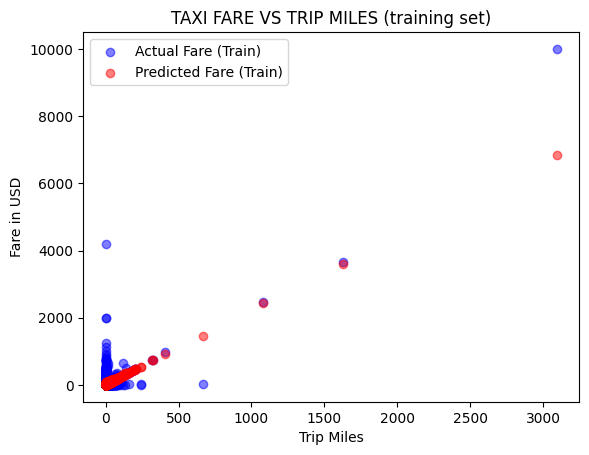

In [17]:
# Plot for Training dataset
y_train_pred = model.predict(x_train)
plt.scatter(x_train['Trip Miles'], y_train, color='blue', label='Actual Fare (Train)', alpha=0.5)
plt.scatter(x_train['Trip Miles'], y_train_pred, color='red', label='Predicted Fare (Train)', alpha=0.5)
plt.title('TAXI FARE VS TRIP MILES (training set)')
plt.xlabel('Trip Miles')
plt.ylabel('Fare in USD')
plt.legend()
plt.show()

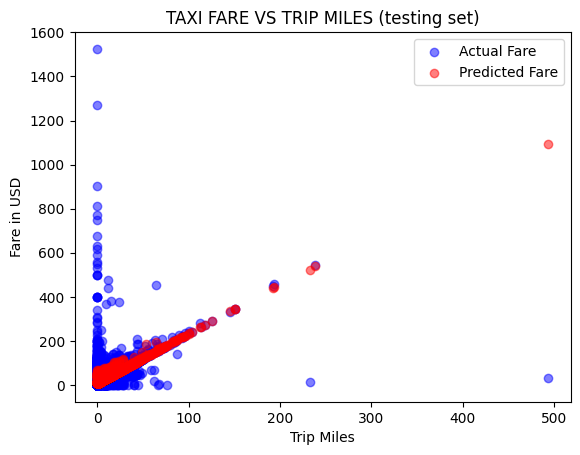

In [11]:
# Plot for Testing dataset
plt.scatter(x_test['Trip Miles'], y_test, color='blue', label='Actual Fare', alpha=0.5)
plt.scatter(x_test['Trip Miles'], y_pred, color='red', label='Predicted Fare', alpha=0.5)
plt.title('TAXI FARE VS TRIP MILES (testing set)')
plt.xlabel('Trip Miles')
plt.ylabel('Fare in USD')
plt.legend()
plt.show()